# <h1 id = "TensorFlow and Keras" style="font-family: 'Cambria', Georgia, serif; font-weight: bold; border-bottom: 3px solid #000; padding: 8px; margin-bottom: 20px; text-align: left; letter-spacing: 1px;"> The Introduction to deep Learning </h1>

Deep Learning (DL) is a ML technique that uses deep neural networks (DNN's) as models.

A deep neural network is a model inspired by animal brains. It's composed of interconnected nodes (or neurons) arranged in layers which process a signal (a real number) and send it to other node layers, until the signal reaches an output layer and the final result can be obtained.

Depending on the structure of the connections and the nature of the operations, DNN's can be classified into many subtypes (multilayer perceptrons, convolutional neural networks, recursive neural networks, etc).

So far, we've only seen techniques that deal with tabular data; data which fits neatly into tables. But not all data can fit into tables, and not all techniques with good results for tabular data can be used on non-tabular data. This is where DL comes in.

DL can be used for both regression and classification problems that deal with non-tabular data such as images, video, audio,etc. DNN's have been proven to be very reliable models that have pushed the ML field forward, but they're very complex and hard to train.

## <h1 id = "TensorFlow and Keras" style="font-family: 'Cambria', Georgia, serif; font-weight: bold; border-bottom: 3px solid #000; padding: 8px; margin-bottom: 20px; text-align: left; letter-spacing: 1px;">1 | TensorFlow and Keras </h1>


* Installing TensorFlow
* Loading images

TensorFlow is a library for ML and AI. Keras is a library that provides a Python interface for TensorFlow, making it simpler to use. Keras used to be an independent library but has been absorved into TensorFlow.

In [1]:
import tensorflow as tf
import numpy as np
from tensorflow import keras

2025-01-16 20:06:00.291305: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-01-16 20:06:00.455204: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1737057960.507351    5991 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1737057960.521603    5991 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-01-16 20:06:00.644172: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instr

In [2]:
# loading of image using the tensorflow and keras
from tensorflow.keras.preprocessing.image import load_img

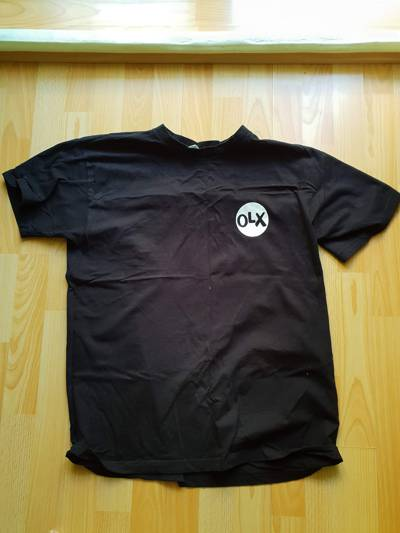

In [3]:
# path to the image
path = './clothing-dataset-small/train/t-shirt'
name = '5f0a3fa0-6a3d-4b68-b213-72766a643de7.jpg'
fullname = f'{path}/{name}'
load_img(fullname)

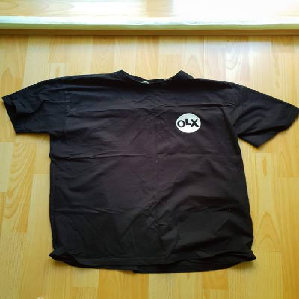

In [4]:
# resizing the image, and assigning it to the img variable
img = load_img(fullname, target_size=(299, 299))
img

When loading an image with `load_img()`, the resulting object is a `PIL image`. PIL stands for Python Image Library;     

PIL used to be a library but it was abandoned and nowadays the Pillow library is used instead, but the image format is the same.

A PIL image object is essentially an array. In the case of color images, a PIL image will have 3 channels, one for each RGB color. A channel is a matrix where each component represents a pixel, and its value ranges from 0 to 255 (1 byte). Thus, a pixel is composed of 3 different values, one for each elemental color, and these values are found in the same position in the 3 matrices.

Neural networks that deal with images expect the images to all have the same size. target_size inside load_img() allows us to define a final size in pixels for the converted image, as in `load_img(target_size=(299, 299)).`

The final size of the PIL image can be calculated as (h, w, c), where h is the height of the image, w is the width and c is the number of channels in the image.

Tensor flow represent an array with three colour channels (red, green, blue) for each pixel in the image. The pixel values are between 0 and 255. The images are resized to 150x150 pixels as the input size for the model.

We can convert the images to a numpy array using the np.array() function. The shape of the array is (150, 150, 3) for each image. The shape of the array is (150, 150, 3, 2000) for 2000 images. The first three dimensions represent the height, width, and colour channels of the image. The fourth dimension represents the number of images.

<div style="text-align: center;">

<img src="/teamspace/studios/this_studio/png/image-3.png" alt="Description" width="500" height="300">

</div>

Each of these line `[179, 171,  99]` represent the green, red, and blue values of a pixel in the image. The pixel values are between 0 and 255. The pixel values are divided by 255 to scale the values between 0 and 1. The pixel values are between 0 and 1.

In [5]:
x = np.array(img)
x.shape

(299, 299, 3)

## <h1 id = "TensorFlow and Keras" style="font-family: 'Cambria', Georgia, serif; font-weight: bold; border-bottom: 3px solid #000; padding: 8px; margin-bottom: 20px; text-align: left; letter-spacing: 1px;">2 | Pre-trained convolutional neural networks </h1>

Training a convolutional neural network from scratch is a time-consuming process and requires a lot of data and powerful hardware. It may take weeks of nonstop training for large datasets like ImageNet with 14 million images. (Check image-net.org for more information.)

Luckily, we don’t need to do it ourselves: we can use pretrained models. Usually, these models are trained on ImageNet and can be used for general-purpose image classification.


It’s very simple, and we don’t even need to download anything ourselves — Keras will take care of it automatically. We can use many different types of models (called architectures). You can find a good summary of available pretrained models in the official Keras documentation: https://www.keras.io/api/applications/


For this chapter, we’ll use `Xception`, a relatively small model that has good performance. First, we need to import the model itself and some helpful functions:

In [6]:
# importing the preprocess_input and decode_predictions functions from the xception module from keras.applications
from tensorflow.keras.applications.xception import Xception
from tensorflow.keras.applications.xception import preprocess_input
from tensorflow.keras.applications.xception import decode_predictions

We imported three things:

- Xception: the actual model 
- preprocess_input: a function for preparing the image to be used by the model 
- decode_prediction: a function for decoding the model’s prediction

### Loading the model

In [7]:
# loading the Xception model, and setting the input shape to 299x299 pixels
model = Xception(weights='imagenet', input_shape=(299, 299, 3))

2025-01-11 17:32:13.664204: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


We specify two parameters here:

- `weights`: We want to use a pretrained model from ImageNet.

- `imput_shape`: The size of the input images: height, width, and the number of channels. We resize the images to 299 × 299, and each image has three channels: red, green and blue.

When we load it for the first time, it downloads the actual model from the internet. After it’s done, we can use it.


Let’s test it on the image we imported previously. First, we load it using the `load_img` function:

In [8]:
img = load_img(fullname, target_size=(299, 299))

The `img` variable is an Image object, which we need to convert to a NumPy array. It’s easy to do using numpy.array:

In [9]:
# Prepare the input image
X = np.array([x])  

This array should have the same shape as the image. Let’s check it:

In [10]:
x.shape

(299, 299, 3)

We see (299, 299, 3). It contains three dimensions as shown above. The first two dimensions represent the height and width of the image, and the third dimension represents the number of channels. The image has three channels: red, green, and blue.

 The width of the image: 299  The height of the image: 299  The number of channels: red, green, blue

<div style="text-align: center;">

<img src="/teamspace/studios/this_studio/png/image-4.png" alt="Description" width="500" height="300">

</div>

The above imgae confirm the shape of the image. The image is 299 pixels wide, 299 pixels tall, and has three channels. The image is a color image.

This matches the input shape we specified when loading the neural network. However, the model doesn’t expect to get just a single image. It gets a batch of images several images put together in one array. This array should have four dimensions:

- The number of images 
- Width of the image
- Height of the image 
- Number of color channels (RGB)


Example:
- For 10 images, the shape is `(10, 299, 299, 3)`.
- For 1 image, the shape is `(1, 299, 299, 3)`.

Thus, we can either create a single batch with one image or create a batch with multiple images. 

**1. Creating a Batch for One Image**

If you have only one image, wrap it in a batch like this:
```python
X = np.array([x])
``` 
This turns the single image into a batch with shape (1, 299, 299, 3). 



**2. Batch for Multiple Images**

If you have several images, like x, y, and z, create a batch with:

```python
X = np.array([x, y, z])

```
This creates a batch with shape (3, 299, 299, 3).



As we can see from the shape of the image, it’s `(1, 299, 299, 3)` — it’s one image of size 299 × 299 with three channels.

Before we can apply the model to our image, we need to prepare it with the `preprocess_input function`:

**Preprocessing the Batch**

The `preprocess_input` function prepares the image to be used by the model. It scales the pixel values to the range of -1 to 1. This is necessary because the model was trained on images with pixel values in this range.
    

In [11]:
X = preprocess_input(X)


In [12]:
X

array([[[[ 0.4039216 ,  0.3411765 , -0.2235294 ],
         [ 0.4039216 ,  0.3411765 , -0.2235294 ],
         [ 0.41960788,  0.35686278, -0.20784312],
         ...,
         [ 0.96862745,  0.9843137 ,  0.94509804],
         [ 0.96862745,  0.9843137 ,  0.94509804],
         [ 0.96862745,  0.99215686,  0.9372549 ]],

        [[ 0.47450984,  0.4039216 , -0.12156862],
         [ 0.4666667 ,  0.39607847, -0.12941176],
         [ 0.45882356,  0.38823533, -0.15294117],
         ...,
         [ 0.96862745,  0.9764706 ,  0.9372549 ],
         [ 0.96862745,  0.9764706 ,  0.9372549 ],
         [ 0.96862745,  0.9764706 ,  0.92941177]],

        [[ 0.56078434,  0.48235297, -0.00392157],
         [ 0.5686275 ,  0.4901961 ,  0.00392163],
         [ 0.5686275 ,  0.49803925, -0.01176471],
         ...,
         [ 0.9607843 ,  0.96862745,  0.92156863],
         [ 0.9607843 ,  0.96862745,  0.92156863],
         [ 0.9607843 ,  0.96862745,  0.92156863]],

        ...,

        [[ 0.2941177 ,  0.18431377, -0

This converts pixel values from 0 to 255 into values between -1 and 1, which the model expects... Following this, we can apply the model to the image:

**Applying the Model**

The model returns a prediction for each image in the batch. In our case, we have only one image, so we get one prediction. The prediction is a NumPy array with 1000 elements, each representing the probability of the image belonging to a specific class. The classes are the same as in ImageNet.

To apply the model, use the predict method:

In [13]:
pred = model.predict(X)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 759ms/step


Let’s take a look at this array:

In [14]:
pred.shape

(1, 1000)

This array is quite large — it contains 1,000 elements (figure 7.8).

The array contains 1000 elements, each representing the probability of the image belonging to a specific class. The classes are the same as in ImageNet. The array contains the probabilities of the image belonging to each of the 1000 classes.

We don’t know what these classes are, so it’s difficult to make sense from this prediction just by looking at the numbers. Luckily, we can use a function, `decode_ predictions`, that decodes the prediction into meaningful class names:

In [15]:
# Decode predictions to human-readable format
decoded = decode_predictions(pred)

In [16]:
# It shows the top five most likely classes for this image:
decoded

[[('n03595614', 'jersey', 0.68196297),
  ('n02916936', 'bulletproof_vest', 0.03814005),
  ('n04370456', 'sweatshirt', 0.03432477),
  ('n03710637', 'maillot', 0.011354217),
  ('n04525038', 'velvet', 0.0018453599)]]

Not quite the result we expected. Most likely, images like this T-shirt are not common in ImageNet, and that’s why the result isn’t useful for our problem.

Even though these results aren’t particularly helpful for us, we can use this neural network as a base model for solving our problem.

To understand how we can do it, we should first get a feeling for how convolutional neural networks work. Let’s see what happens inside the model when we invoke the predict method.

### Internal Structure of the Model

All neural networks are organized in layers. We take an image, pass it through all the layers, and, at the end, get the predictions (figure 7.9).

<div style="text-align: center;">

<img src="/teamspace/studios/this_studio/png/image-5.png" alt="Description" width="500" height="300">

</div>

Usually, a model has a lot of layers. For example, the Xception model we use here has 71 layers. That’s why these neural networks are called “deep” neural networks because they have many layers.

For a convolutional neural network, the most important layers are

1. Convolutional layers 
2. Dense layers

First, let’s take a look at convolutional layers.

### Convolutional Layers

**What is a Convolutional Layer?**  


A convolutional layer is like a collection of `small patterns or filters` (tiny images with shapes like stripes or edges). These filters help the model recognize specific shapes or patterns in an image.

**Filters and Training**
- During training, the model **learns these filters** based on the task (e.g., detecting cats or cars).
- When using a **pretrained model**, these filters are already trained, so you don’t need to worry about them.

**How It Works**
1. The model slides each filter across the image.
2. This sliding happens in two directions:
   - **Left to right**
   - **Top to bottom**

**Matching the Filter to the Image**
- As the filter moves, it compares its pattern to the part of the image it's on.
- For every comparison, the model records a score:
  - **High score**: The filter matches the image well.
  - **Low score**: The filter doesn’t match.

**Feature Map**
- The result of sliding the filter over the image is called a **feature map**.
- A feature map is like a map showing where the filter’s pattern was found in the image:
  - **Bright spots (high numbers)**: Strong matches.
  - **Dark spots (low numbers)**: Weak or no matches.

**Purpose**
- The feature map helps the model understand where specific shapes (like edges or stripes) are located in the image.
- These shapes are combined in later layers to recognize more complex features, like:
  - **Eyes**
  - **Wheels**
  - **Entire objects**

**Summary**
A convolutional layer looks for patterns in an image using filters, creates a map of where those patterns appear, and uses this information to identify features in the image.


<div style="text-align: center;">

<img src="/teamspace/studios/this_studio/png/image-6.png" alt="Description" width="500" height="300">

</div>

The filters in a convolutional layer are learned by the model during training. However, because we are using a pretrained neural network, we don’t need to worry about it; we already have the filters. To apply a convolutional layer to a picture, we slide each filter across this image. For example, we can slide it from left to right and from top to bottom 

<div style="text-align: center;">

<img src="/teamspace/studios/this_studio/png/image-7.png" alt="Description" width="500" height="300">

</div>

While sliding, we compare the content of the filter with the content of the image under the filter. For each comparison, we record the degree of similarity. This way, we get a feature map — an array with numbers, where a large number means a match between the filter and the image, and a low number means no match (figure 7.12).

So, a feature map tells us where on the image we can find the shape from the filter.

<div style="text-align: center;">

<img src="/teamspace/studios/this_studio/png/image-8.png" alt="Description" width="500" height="300">

</div>

One convolutional layer consists of many filters, so we actually get multiple feature maps — one for each filter (figure 7.13).

<div style="text-align: center;">

<img src="/teamspace/studios/this_studio/png/image-9.png" alt="Description" width="500" height="300">

</div>

The feature maps are then passed to the next layer, where they are combined to recognize more complex shapes. This process is repeated many times, and the model learns to recognize more and more complex shapes. Thus, the model can recognize entire objects.

The deeper the layer is, the more complex the shapes it can recognize. The last layers of the model are dense layers, which are responsible for making the final decision. Also note thaty as the we go deep into the layers, the size of the image decreases, and the number of channels increases, and level of abstraction increases.

<div style="text-align: center;">

<img src="/teamspace/studios/this_studio/png/image-10.png" alt="Description" width="500" height="300">

</div>

We repeat this process to detect more and more complex shapes. This way, the network “learns” some distinctive features of the image. For clothes, it can be short or long sleeves or the type of neck. For animals, it can be pointy or floppy ears or the presence of whiskers.

At the end, we get a vector representation of an image: a one-dimensional array, where each position corresponds to some high-level visual features. Some parts of the array may correspond to sleeves, whereas other parts represent ears and whiskers. At this level, it’s usually difficult to make sense from these features, but they have enough discriminative power to distinguish between a T-shirt and pants or between a cat and a dog.

Now we need to use this vector representation to combine these high-level features and arrive at the final decision. For that, we use a different kind of layers — dense layers.

### Dense Layers

The output of the convolutional layers is a vector representation, and that serves as an input to the Dense layers. Dense layers are the final layers of the model, and they are responsible for making the final decision. Dense layers process the vector representation of an image and translate these visual features to the actual class — T-shirt, dress, jacket, or other class (figure 7.15).

<div style="text-align: center;">

<img src="/teamspace/studios/this_studio/png/image-11.png" alt="Description" width="500" height="300">

</div>

Consider the dense layers as a decision machine, and from the image above, we just have a single dense layer, but in reality, dense layers are multiple connection of neuron that convert the input to the output. it is called “dense” because it connects each element of the input with all the elements of its output. For this reason, these layers are sometimes called “fully connected” (figure 7.19).

<div style="text-align: center;">

<img src="/teamspace/studios/this_studio/png/image-12.png" alt="Description" width="500" height="300">

</div>

So, when we invoke predict, the image first goes through a series of convolutional layers. This way, we extract the vector representation of this image. Next, this vector representation goes through a series of dense layers, and we get the final prediction (figure 7.21).

<div style="text-align: center;">

<img src="/teamspace/studios/this_studio/png/image-13.png" alt="Description" width="500" height="300">

</div>

### Training the model
___

Training a convolutional neural network takes a lot of time and requires a lot of data. But there’s a shortcut: we can use transfer learning, an approach where we adapt a pretrained model to our problem.

### Transfer learning 
____

The difficulty in training usually comes from convolutional layers. To be able to extract a good vector representation from an image, the filters need to learn good patterns. For that, the network has to see many different images — the more, the better. But once we have a good vector representation, training dense layers is relatively easy.

This means that we can take a neural network pretrained on ImageNet and use it for solving our problem. This model has already learned good filters. So, we take this model and keep the convolutional layers, but drop the dense layers and instead train new ones (figure 7.22). Thus, we will take the advantage of the good filters learned by the model and only train the decision-making part.

In this section, we do exactly that. But before we can start training, we need to get our dataset ready.

<div style="text-align: center;">

<img src="/teamspace/studios/this_studio/png/image-14.png" alt="Description" width="500" height="300">

</div>

### Loading the dataset

In previous chapters, we loaded the entire dataset into memory and used it to get X the matrix with features. With images, it’s more difficult: we may not have enough memory to keep all the images.

Keras comes with a solution — `ImageDataGenerator`. Instead of loading the entire dataset into memory, it loads the images from disk in small batches. Let’s use it:

In [25]:
# importing the ImageDataGenerator class from the tensorflow.keras.preprocessing.image module
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [18]:
# creating an instance of the ImageDataGenerator class with the preprocess_input function
train_gen = ImageDataGenerator(preprocessing_function=preprocess_input)

We already know that images need to be preprocessed using the `preprocess_input` function. That’s why we need to tell `ImageDataGenerator` how the data should be prepared.

We have a generator now, so we just need to point it to the directory with the data. For that, use the `flow_from_directory` method:

In [19]:
# using the flow_from_directory method to load the images from the directory
# resizing the images to 150x150 pixels, and setting the batch size to 32
train_ds = train_gen.flow_from_directory(
    './clothing-dataset-small/train',
    target_size=(150, 150),
    batch_size=32
)

Found 3068 images belonging to 10 classes.


<div style="text-align: center;">

<img src="/teamspace/studios/this_studio/png/image-15.png" alt="Description" width="500" height="300">

</div>

We have 10 classes of clothing in our dataset, and images of each class are stored in a separate directory. For example, all T-shirts are stored in the t-shirt folder. The generator can use the folder structure to infer the label for each image.

When we execute the cell, it informs us how many images there are in the train dataset and how many classes:

In [20]:
# displaying the class indices
train_ds.class_indices

{'dress': 0,
 'hat': 1,
 'longsleeve': 2,
 'outwear': 3,
 'pants': 4,
 'shirt': 5,
 'shoes': 6,
 'shorts': 7,
 'skirt': 8,
 't-shirt': 9}

In [21]:
# another way to display the class indices but without the index
! ls -1 ./clothing-dataset-small/train

dress
hat
longsleeve
outwear
pants
shirt
shoes
shorts
skirt
t-shirt


The same generator can be used for the validation dataset. We just need to point it to the validation directory:

In [26]:
validataion_gen = ImageDataGenerator(preprocessing_function=preprocess_input)

valid_ds = validataion_gen.flow_from_directory(
    './clothing-dataset-small/validation',
    target_size=(150, 150),
    batch_size=32
)


Found 341 images belonging to 10 classes.


In [27]:
# displaying the class indices
valid_ds.class_indices

{'dress': 0,
 'hat': 1,
 'longsleeve': 2,
 'outwear': 3,
 'pants': 4,
 'shirt': 5,
 'shoes': 6,
 'shorts': 7,
 'skirt': 8,
 't-shirt': 9}

Like previously, we use the train dataset for training the model and the validation dataset for selecting the best parameters.

We have loaded the data, and now we’re ready to train a model.

In [23]:
import tensorflow as tf

# Example: Creating a simple dataset
train_ds = tf.data.Dataset.range(10).batch(2)

# Creating an iterator
iterator = iter(train_ds)

# Fetching the next batch
next_batch = next(iterator)
print(next_batch)

tf.Tensor([0 1], shape=(2,), dtype=int64)




In this example, `next(iterator)` retrieves the next batch of data from the dataset `train_ds`.

Applying the `next()` function to an iterator allows you to iterate through the dataset one batch at a time. This is useful when training a model using a dataset that is too large to fit into memory all at once.

The line `X, y = next(train_ds)` is used to retrieve the next batch of data from the dataset train_ds and unpack it into two variables, `X` and `y`.   

Explanation:  
* `train_ds`:  

This is assumed to be an iterator or an iterable object, such as a TensorFlow dataset.

* `next(train_ds)`:

- The `next()` function is called on `train_ds` to get the next batch of data.
- This returns a tuple containing the features and labels (or inputs and targets).

* Unpacking the Tuple:

The returned tuple is unpacked into two variables: X and y.
`X` typically contains the input data (features).
`y` typically contains the target data (labels).


______

### 8.4 Transfer learning

In [24]:
# Fetching the next batch for X and y
X, y = next(train_ds)

TypeError: '_BatchDataset' object is not an iterator

In [ ]:
# Displaying the shape of X 
X.shape, 

((32, 150, 150, 3),)

In [ ]:
# Displaying the shape of X and y
y.shape

(32, 10)

From the assignmemtn of variable X, and y, we can see that the `X` variable contains the input data (images) and the `y` variable contains the corresponding labels for the images. We can specific view a desire element from the class as shown in the code below.

```python
import matplotlib.pyplot as plt
plt.imshow(X[0])
plt.show()


print(y[0])
```

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


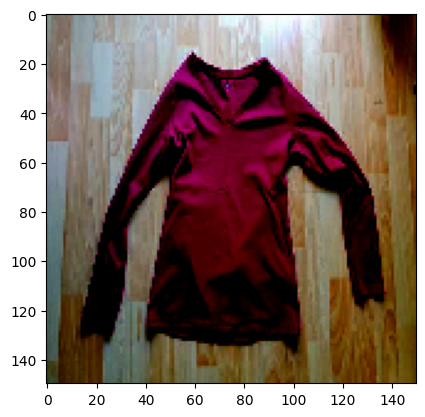

[0. 0. 1. 0. 0. 0. 0. 0. 0. 0.]


In [ ]:
# Displaying the first image
import matplotlib.pyplot as plt
plt.imshow(X[0])
plt.show()


print(y[0])

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


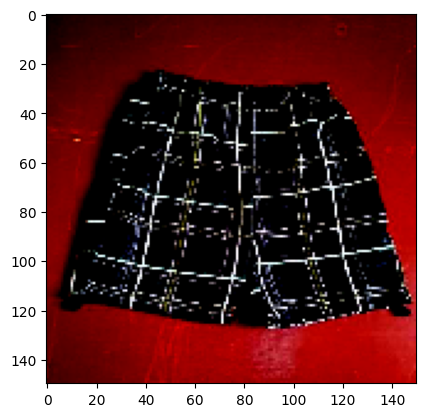

[0. 0. 0. 0. 0. 0. 0. 1. 0. 0.]


In [ ]:
# Displaying the shape of X and y
import matplotlib.pyplot as plt
plt.imshow(X[5])
plt.show()

# Displaying the label of the 8th image
print(y[5])

In [ ]:
X, y = next(train_ds)

In [ ]:
y[:5]

array([[0., 0., 0., 0., 0., 0., 0., 0., 0., 1.],
       [0., 0., 0., 0., 1., 0., 0., 0., 0., 0.],
       [0., 0., 1., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 1., 0., 0., 0., 0.],
       [0., 0., 0., 0., 1., 0., 0., 0., 0., 0.]], dtype=float32)

<div style="text-align: center;">

<img src="/teamspace/studios/this_studio/my-image-notes/image-1.png" alt="Description" width="500" height="300">

</div>

The example above is a multi-class classification problem, where the labels are one-hot encoded.

After setting up the train model, we can set uo the val model as shown below using the syntax :

```python
val_ds = val_gen.flow_from_directory(
    './clothing-dataset-small/validation',
    target_size=(150, 150),
    batch_size=32,
    shuffle=False
)
````

In [ ]:
# setting up the validation dataset
val_gen = ImageDataGenerator(preprocessing_function=preprocess_input)

val_ds = val_gen.flow_from_directory(
    './clothing-dataset-small/validation',
    target_size=(150, 150),
    batch_size=32,
    shuffle=False
)

Found 341 images belonging to 10 classes.
